In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import random
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

reading in the predictor data

In [ ]:
first = pd.read_csv("/content/drive/MyDrive/Crude Oil WTI Futures Historical Data (19-24).csv")
first

,Date,Price,Open,High,Low,Vol.,Change %
0,12/31/2024,71.25,70.69,71.52,70.43,63.63K,1.02%
1,12/30/2024,70.53,70.00,71.05,69.75,93.10K,0.50%
2,12/27/2024,70.18,69.27,70.32,69.06,79.13K,1.37%
3,12/26/2024,69.23,69.72,70.25,68.94,69.64K,-0.59%
4,12/24/2024,69.64,69.04,69.94,68.95,40.39K,1.21%
...,...,...,...,...,...,...,...
1511,04/03/2019,62.52,62.70,63.04,62.11,205.84K,-0.14%
1512,04/02/2019,62.61,61.92,62.80,61.71,314.02K,1.46%
1513,04/01/2019,61.71,60.36,61.90,60.36,172.80K,2.37%
1514,03/29/2019,60.28,59.67,60.87,59.60,140.05K,1.34%


It wouldn't let me download all the data in one pull, so I needed to do a second one

In [ ]:
second = pd.read_csv("/content/drive/MyDrive/Crude Oil WTI Futures Historical Data (99-19).csv")
second

,Date,Price,Open,High,Low,Vol.,Change %
0,03/27/2019,59.61,60.16,60.35,59.01,153.54K,-0.82%
1,03/26/2019,60.10,59.22,60.50,59.22,210.85K,1.73%
2,03/25/2019,59.08,59.24,59.58,58.45,129.81K,-0.35%
3,03/22/2019,59.29,60.09,60.29,58.52,125.19K,-1.51%
4,03/21/2019,60.20,60.25,60.61,59.92,138.51K,-0.05%
...,...,...,...,...,...,...,...
4995,08/06/1999,20.88,20.61,20.92,20.37,67.22K,1.56%
4996,08/05/1999,20.56,20.45,20.64,20.31,38.90K,0.59%
4997,08/04/1999,20.44,20.30,20.75,20.10,58.94K,0.69%
4998,08/03/1999,20.30,20.46,20.53,20.12,51.94K,-0.73%


In [ ]:
third = pd.read_csv("/content/drive/MyDrive/Crude Oil WTI Futures Historical Data (24-26).csv")
third

,Date,Price,Open,High,Low,Vol.,Change %
0,02/03/2026,64.11,61.92,64.21,61.13,343.98K,3.17%
1,02/02/2026,62.14,64.72,64.74,61.39,414.08K,-4.71%
2,01/30/2026,65.21,65.52,66.11,63.64,449.33K,-0.32%
3,01/29/2026,65.42,63.50,66.48,63.28,560.01K,3.50%
4,01/28/2026,63.21,62.58,63.57,62.07,354.86K,1.31%
...,...,...,...,...,...,...,...
277,01/08/2025,72.67,73.81,74.44,72.51,261.48K,-1.22%
278,01/07/2025,73.57,72.81,73.82,72.51,188.74K,0.89%
279,01/06/2025,72.92,73.31,74.18,72.54,221.84K,-0.40%
280,01/03/2025,73.21,72.46,73.50,72.10,220.66K,0.98%


concatenating them, changing dtype and sorting. Also prepping for merge by offsetting

In [ ]:
price = pd.concat([third, second, first], ignore_index=True)
price["Date"] = pd.to_datetime(price["Date"])
price = price.sort_values(by="Date")
price = price[["Date", "Price"]]
# macro_month will be used in the merging with the prior month's macro data
price["macro_month"] = price["Date"].dt.to_period("M").dt.to_timestamp() - pd.DateOffset(months=1)
price

,Date,Price,macro_month
5281,1999-08-02,20.45,1999-07-01
5280,1999-08-03,20.30,1999-07-01
5279,1999-08-04,20.44,1999-07-01
5278,1999-08-05,20.56,1999-07-01
5277,1999-08-06,20.88,1999-07-01
...,...,...,...
4,2026-01-28,63.21,2025-12-01
3,2026-01-29,65.42,2025-12-01
2,2026-01-30,65.21,2025-12-01
1,2026-02-02,62.14,2026-01-01


Reading in the macro data and then doing some initial cleaning

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/2025-12-MD.csv")
# choose the right columns
df = df[["sasdate","RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE",  "USTRADE", "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",  "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",  "PPICMM", "UMCSENTx"]]
# dropping the first row with the transform info
df.drop(index=df.index[0], inplace=True)
# df.info()
df

,sasdate,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
1,1/1/1959,2583.560,2426.0,2.766768e+05,23.6312,2568.7,5350.3,35.2130,124.964676,55.62,...,1.53,1.54,1.64,2.39,4.3122,359.8417,2.8065,0.9671,32.500,NaN
2,2/1/1959,2593.596,2434.8,2.787140e+05,23.9501,2575.4,5381.3,35.2201,125.765075,54.77,...,1.53,1.53,1.71,2.46,4.3133,359.8417,2.8093,0.9748,32.500,NaN
3,3/1/1959,2610.396,2452.7,2.777753e+05,24.0951,2584.4,5431.6,35.1304,126.122900,56.16,...,1.19,1.19,1.33,2.05,4.3228,359.8417,2.8127,0.9698,32.900,NaN
4,4/1/1959,2627.446,2470.0,2.833627e+05,24.4431,2596.9,5395.4,35.5581,126.190123,57.10,...,1.16,1.16,1.27,1.90,4.3226,359.8417,2.8165,0.9636,32.700,NaN
5,5/1/1959,2642.720,2486.4,2.853072e+05,24.6460,2607.4,5456.3,36.3064,126.757555,57.96,...,1.45,1.41,1.47,2.06,4.3228,359.8417,2.8145,0.9630,32.900,95.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,7/1/2025,20559.297,16639.8,1.565917e+06,98.0308,6163.1,15576.4,2674.3188,143.604323,6296.50,...,-0.38,0.06,1.12,1.77,0.7989,147.2014,1.3489,1.3691,368.360,61.7
800,8/1/2025,20585.615,16641.5,1.562592e+06,97.7560,6157.0,15581.8,2685.1565,143.376085,6408.95,...,-0.54,-0.07,1.02,1.67,0.8058,147.4786,1.3456,1.3797,373.092,58.2
801,9/1/2025,20603.322,16654.3,1.551287e+06,97.7772,6165.9,15605.2,2693.7764,143.127140,6584.02,...,-0.57,-0.11,0.98,1.60,0.7961,147.8629,1.3506,1.3834,387.560,55.1
802,10/1/2025,NaN,NaN,NaN,97.6602,6168.2,15602.8,2692.5190,NaN,6735.69,...,-0.43,-0.02,1.05,1.66,0.7975,151.3545,1.3357,1.3988,NaN,53.6


fixing the date column, removing out of scope dates

In [ ]:
# to datetime
df["sasdate"] = pd.to_datetime(df["sasdate"])
# filtering
df = df[df["sasdate"] >= "1999-08-01"]
df

,sasdate,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,...,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx
488,1999-08-01,11111.719,9681.7,1043658.0,98.7651,5864.7,15000.1,969.3807,112.225134,1327.49,...,0.77,0.87,2.33,3.08,1.5093,113.2268,1.6058,1.4932,107.900,104.5
489,1999-09-01,11105.537,9676.6,1041766.0,98.2348,5873.6,15026.8,975.6399,112.442509,1318.17,...,0.58,0.70,2.17,2.98,1.5262,106.8752,1.6247,1.4771,110.800,107.2
490,1999-10-01,11171.257,9739.5,1050919.0,99.4366,5881.0,15062.1,979.0983,112.206296,1300.01,...,0.83,0.91,2.35,3.18,1.4896,105.9650,1.6572,1.4776,112.500,103.2
491,1999-11-01,11247.830,9816.9,1056351.0,99.5019,5894.2,15075.2,1000.2986,112.088054,1391.00,...,0.55,0.61,1.94,2.73,1.5543,104.6485,1.6205,1.4674,113.800,107.2
492,1999-12-01,11339.820,9904.0,1060927.0,100.3457,5904.7,15151.8,1000.6226,111.548561,1428.68,...,0.89,0.98,2.25,2.89,1.5841,102.5843,1.6132,1.4722,115.700,105.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799,2025-07-01,20559.297,16639.8,1565917.0,98.0308,6163.1,15576.4,2674.3188,143.604323,6296.50,...,-0.38,0.06,1.12,1.77,0.7989,147.2014,1.3489,1.3691,368.360,61.7
800,2025-08-01,20585.615,16641.5,1562592.0,97.7560,6157.0,15581.8,2685.1565,143.376085,6408.95,...,-0.54,-0.07,1.02,1.67,0.8058,147.4786,1.3456,1.3797,373.092,58.2
801,2025-09-01,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,143.127140,6584.02,...,-0.57,-0.11,0.98,1.60,0.7961,147.8629,1.3506,1.3834,387.560,55.1
802,2025-10-01,NaN,NaN,NaN,97.6602,6168.2,15602.8,2692.5190,NaN,6735.69,...,-0.43,-0.02,1.05,1.66,0.7975,151.3545,1.3357,1.3988,NaN,53.6


merging the dfs together

In [ ]:
merged = price.merge(df, left_on="macro_month", right_on="sasdate", how="left") \
              .drop(columns=["sasdate"]) \
              .dropna()
# merged["sasdate"].nunique()
merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6710 entries, 22 to 6731
Data columns (total 34 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6710 non-null   datetime64[ns]
 1   Price         6710 non-null   float64       
 2   macro_month   6710 non-null   datetime64[ns]
 3   RPI           6710 non-null   float64       
 4   W875RX1       6710 non-null   float64       
 5   CMRMTSPLx     6710 non-null   float64       
 6   IPFPNSS       6710 non-null   float64       
 7   USWTRADE      6710 non-null   float64       
 8   USTRADE       6710 non-null   float64       
 9   BUSLOANS      6710 non-null   float64       
 10  CONSPI        6710 non-null   float64       
 11  S&P 500       6710 non-null   float64       
 12  S&P PE ratio  6710 non-null   float64       
 13  FEDFUNDS      6710 non-null   float64       
 14  TB3MS         6710 non-null   float64       
 15  TB6MS         6710 non-null   float64     

In [ ]:
merged = merged.sort_values("Date").reset_index(drop=True)

# prior day price level
merged["priceLag1"] = merged["Price"].shift(1)

# drop first row(s) created by shift/diff
merged = merged.dropna().reset_index(drop=True)


In [ ]:
merged.tail()

,Date,Price,macro_month,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPICMM,UMCSENTx,priceLag1
6704,2025-10-27,61.31,2025-09-01,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,...,-0.11,0.98,1.6,0.7961,147.8629,1.3506,1.3834,387.56,55.1,61.50
6705,2025-10-28,60.15,2025-09-01,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,...,-0.11,0.98,1.6,0.7961,147.8629,1.3506,1.3834,387.56,55.1,61.31
6706,2025-10-29,60.48,2025-09-01,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,...,-0.11,0.98,1.6,0.7961,147.8629,1.3506,1.3834,387.56,55.1,60.15
6707,2025-10-30,60.57,2025-09-01,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,...,-0.11,0.98,1.6,0.7961,147.8629,1.3506,1.3834,387.56,55.1,60.48
6708,2025-10-31,60.98,2025-09-01,20603.322,16654.3,1551287.0,97.7772,6165.9,15605.2,2693.7764,...,-0.11,0.98,1.6,0.7961,147.8629,1.3506,1.3834,387.56,55.1,60.57


In [ ]:
# just testing to see if it worked entirely
merged.loc[merged["Date"] == pd.Timestamp("2020-09-02"), ["Date","macro_month"]].head()


,Date,macro_month
5354,2020-09-02,2020-08-01


splitting data into training/validation/test sets

In [ ]:
train_end = pd.Timestamp("2014-12-31")
val_end = pd.Timestamp("2024-12-31")


train = merged[merged["Date"] <= train_end].reset_index(drop=True)
val = merged[(merged["Date"] > train_end) & (merged["Date"] <= val_end)].reset_index(drop=True)
test = merged[merged["Date"] > val_end].reset_index(drop=True)

dev = merged[merged["Date"] <= val_end].reset_index(drop=True)
test = merged[merged["Date"] > val_end].reset_index(drop=True)

print("DEV:", dev.shape, "| TEST:", test.shape)
print("DEV:", dev["Date"].min(), "-", dev["Date"].max())
print("TEST:", test["Date"].min(), "-", test["Date"].max())

DEV: (6493, 35) | TEST: (216, 35)
DEV: 1999-09-02 00:00:00 - 2024-12-31 00:00:00
TEST: 2025-01-02 00:00:00 - 2025-10-31 00:00:00


lookback windows

In [ ]:
LOOKBACK = 30
HORIZON = 1
N_FOLDS = 5

merged = merged.sort_values("Date").reset_index(drop=True)

splits the data into 5 folds

In [ ]:
def makeTimeFolds(devdf, nfolds=5):
    devdf = devdf.sort_values("Date").reset_index(drop=True)

    valStartGlobal = pd.Timestamp("2015-01-01")
    valEndGlobal   = pd.Timestamp("2024-12-31")

    mask = (devdf["Date"] >= valStartGlobal) & (devdf["Date"] <= valEndGlobal)
    valdf = devdf[mask].reset_index(drop=True)

    n = len(valdf)
    foldSizes = [n // nfolds] * nfolds
    for i in range(n % nfolds):
        foldSizes[i] += 1

    folds = []
    start = 0
    for i, fs in enumerate(foldSizes):
        end = start + fs
        foldVal = valdf.iloc[start:end].copy()

        valStart = foldVal["Date"].min()
        valEnd   = foldVal["Date"].max()

        foldTrain = devdf[devdf["Date"] < valStart].copy()

        folds.append((foldTrain.reset_index(drop=True), foldVal.reset_index(drop=True), (valStart, valEnd)))
        start = end

    return folds

folds = makeTimeFolds(dev, nfolds=N_FOLDS)

for i, (tr, va, (a, b)) in enumerate(folds, 1):
    print(f"Fold {i}: train {tr['Date'].min()}-{tr['Date'].max()} ({len(tr)}) | val {a}-{b} ({len(va)})")
    print("\n")


Fold 1: train 1999-09-02 00:00:00-2014-12-31 00:00:00 (3858) | val 2015-01-01 00:00:00-2016-12-29 00:00:00 (527)


Fold 2: train 1999-09-02 00:00:00-2016-12-29 00:00:00 (4385) | val 2016-12-30 00:00:00-2018-12-28 00:00:00 (527)


Fold 3: train 1999-09-02 00:00:00-2018-12-28 00:00:00 (4912) | val 2018-12-31 00:00:00-2020-12-29 00:00:00 (527)


Fold 4: train 1999-09-02 00:00:00-2020-12-29 00:00:00 (5439) | val 2020-12-30 00:00:00-2022-12-27 00:00:00 (527)


Fold 5: train 1999-09-02 00:00:00-2022-12-27 00:00:00 (5966) | val 2022-12-28 00:00:00-2024-12-31 00:00:00 (527)




In [ ]:
feature_cols = ["RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
                "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS", "TB3MS",
                "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM",
                "T1YFFM", "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx",
                "EXUSUKx", "EXCAUSx", "PPICMM", "UMCSENTx", "priceLag1"]

FAVAR Implementation (with PCA)

In [ ]:
class FAVAR:
    def __init__(self, nfactors=5, varlags=30, horizon=1):
        self.nfactors = int(nfactors)
        self.varlags = int(varlags)
        self.horizon = int(horizon)

        self.scaler = None
        self.pca = None
        self.varres = None
        self.endogcols = None

    def fit(self, traindf, featurecols):
        traindf = traindf.sort_values("Date").reset_index(drop=True).copy()
        traindf = traindf.dropna(subset=featurecols + ["Price"])

        X = traindf[featurecols].to_numpy(dtype=float)
        y = traindf["Price"].to_numpy(dtype=float)

        # train-only scaling
        self.scaler = StandardScaler()
        Xs = self.scaler.fit_transform(X)

        # train-only PCA
        self.pca = PCA(n_components=self.nfactors, random_state=SEED)
        F = self.pca.fit_transform(Xs)

        endog = pd.DataFrame(F, columns=[f"F{i+1}" for i in range(self.nfactors)])
        endog["Price"] = y

        self.endogcols = list(endog.columns)

        model = VAR(endog)
        self.varres = model.fit(self.varlags)

        return self

    def _endogFromDf(self, df, featurecols):
        df = df.sort_values("Date").reset_index(drop=True).copy()
        df = df.dropna(subset=featurecols + ["Price"])

        X = df[featurecols].to_numpy(dtype=float)
        y = df["Price"].to_numpy(dtype=float)

        Xs = self.scaler.transform(X)
        F = self.pca.transform(Xs)

        endog = pd.DataFrame(F, columns=[f"F{i+1}" for i in range(self.nfactors)])
        endog["Price"] = y

        endog = endog[self.endogcols]
        return endog, y

    def rollingPredictOneStep(self, historydf, targetdf, featurecols):
        """
        Fit is already done on history training set.
        Here we generate rolling 1-step ahead forecasts for the targetdf period,
        using observed history up to t-1 each time.

        Not refitting VAR. forecasting forward with fixed params
        """
        p = self.varlags
        h = self.horizon

        # Build endog for combined (history + target), because we need observed lags.
        comb = pd.concat([historydf, targetdf], ignore_index=True).sort_values("Date").reset_index(drop=True)
        endog, y = self._endogFromDf(comb, featurecols)

        nHist = len(historydf.dropna(subset=featurecols + ["Price"]))
        preds = np.full(len(endog), np.nan, dtype=float)

        priceIndex = endog.columns.get_loc("Price")

        # Rolling forecast only over the target range indices
        for i in range(nHist, len(endog)):
            if i < p:
                continue
            lastp = endog.iloc[i-p:i].to_numpy()
            yhatPath = self.varres.forecast(lastp, steps=h)
            preds[i] = yhatPath[-1, priceIndex]

        # Return predictions aligned to the TARGET portion only
        return preds[nHist:], y[nHist:]

    def metrics(self, yhat, ytrue):
        yhat = np.asarray(yhat, dtype=float)
        ytrue = np.asarray(ytrue, dtype=float)

        mask = ~np.isnan(yhat) & ~np.isnan(ytrue)
        eps = 1e-8

        rmse = float(np.sqrt(np.mean((yhat[mask] - ytrue[mask]) ** 2)))
        mae  = float(np.mean(np.abs(yhat[mask] - ytrue[mask])))
        mape = float(np.mean(np.abs((yhat[mask] - ytrue[mask]) / (ytrue[mask] + eps))) * 100.0)

        ssres = float(np.sum((ytrue[mask] - yhat[mask]) ** 2))
        sstot = float(np.sum((ytrue[mask] - np.mean(ytrue[mask])) ** 2))
        r2 = float(1.0 - ssres / (sstot + eps))

        return {"rmse": rmse, "mae": mae, "r2": r2, "mape": mape}


In [ ]:
candidateFactors = [3, 5, 8, 10]
results = []

for nf in candidateFactors:
    foldMetrics = []

    for i, (tr, va, (a, b)) in enumerate(folds, 1):
        try:
            model = FAVAR(nfactors=nf, varlags=LOOKBACK, horizon=HORIZON)
            model.fit(tr, feature_cols)

            yhat, ytrue = model.rollingPredictOneStep(tr, va, feature_cols)
            m = model.metrics(yhat, ytrue)

            foldMetrics.append(m)
            print(f"nfactors={nf} | fold {i} ({a.date()}→{b.date()}):", m)

        except Exception as e:
            print(f"nfactors={nf} | fold {i} failed:", repr(e))
            foldMetrics.append({"rmse": np.nan, "mae": np.nan, "r2": np.nan, "mape": np.nan})

    avg = {}
    for k in ["rmse", "mae", "r2", "mape"]:
        vals = [fm[k] for fm in foldMetrics if not np.isnan(fm[k])]
        avg[k] = float(np.mean(vals)) if len(vals) else np.nan

    results.append({"nfactors": nf, **avg})
    print("AVG nfactors=", nf, avg, "\n")

cvResults = pd.DataFrame(results).sort_values("rmse")
cvResults


nfactors=3 | fold 1 (2015-01-01→2016-12-29): {'rmse': 1.3397858230845214, 'mae': 1.065450455431092, 'r2': 0.9663920983287028, 'mape': 2.40293370041113}
nfactors=3 | fold 2 (2016-12-30→2018-12-28): {'rmse': 1.005925331613892, 'mae': 0.7617911602224942, 'r2': 0.9864381547518194, 'mape': 1.3319426551829066}
nfactors=3 | fold 3 (2018-12-31→2020-12-29): {'rmse': 1.5337249975185538, 'mae': 1.014991024675057, 'r2': 0.9804423142515006, 'mape': 2.6066303497264522}
nfactors=3 | fold 4 (2020-12-30→2022-12-27): {'rmse': 2.3295649151574898, 'mae': 1.616567389740042, 'r2': 0.9796755405099944, 'mape': 1.9289377862010453}
nfactors=3 | fold 5 (2022-12-28→2024-12-31): {'rmse': 1.432717302574592, 'mae': 1.126841742811787, 'r2': 0.9296509413641876, 'mape': 1.4877574347675349}
AVG nfactors= 3 {'rmse': 1.5283436739898097, 'mae': 1.1171283545760944, 'r2': 0.9685198098412411, 'mape': 1.9516403852578137} 

nfactors=5 | fold 1 (2015-01-01→2016-12-29): {'rmse': 1.3283639472640265, 'mae': 1.0563567630846937, 'r2'

,nfactors,rmse,mae,r2,mape
0,3,1.528344,1.117128,0.968520,1.951640
1,5,1.559117,1.132834,0.967757,1.995554
2,8,1.584208,1.151226,0.966893,2.023176
3,10,1.662210,1.186422,0.964278,2.117517


In [ ]:
bestN = int(cvResults.iloc[0]["nfactors"])
print("Best nfactors:", bestN)


Best nfactors: 3


In [ ]:
finalModel = FAVAR(nfactors=bestN, varlags=LOOKBACK, horizon=HORIZON)
finalModel.fit(dev, feature_cols)

yhatTest, ytrueTest = finalModel.rollingPredictOneStep(dev, test, feature_cols)
testMetrics = finalModel.metrics(yhatTest, ytrueTest)

print("=== FINAL TEST METRICS (FAVAR) ===")
testMetrics


=== FINAL TEST METRICS (FAVAR) ===


{'rmse': 1.3754473061462114,
 'mae': 1.0260062545224995,
 'r2': 0.91918095959826,
 'mape': 1.562037469227088}

The predicted values are very good, but lagged a little bit from the true behavior

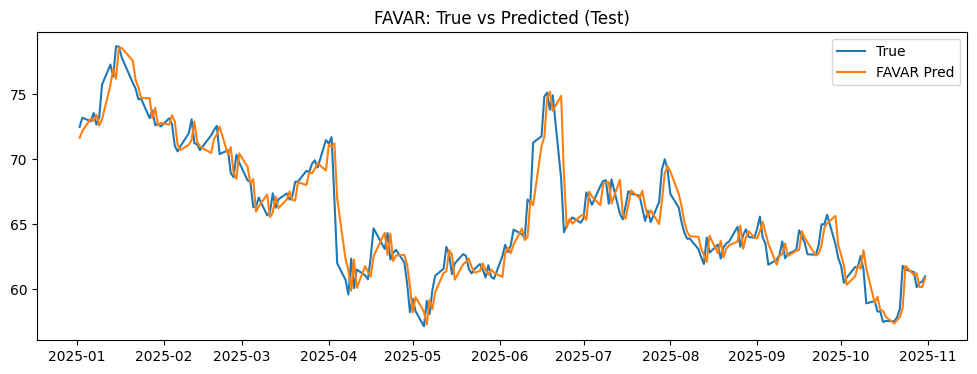

In [ ]:
plotdf = test.copy().reset_index(drop=True)
plotdf = plotdf.iloc[:len(ytrueTest)].copy()
plotdf["ytrue"] = ytrueTest
plotdf["yhat"] = yhatTest

plt.figure(figsize=(12, 4))
plt.plot(plotdf["Date"], plotdf["ytrue"], label="True")
plt.plot(plotdf["Date"], plotdf["yhat"], label="FAVAR Pred")
plt.legend()
plt.title("FAVAR: True vs Predicted (Test)")
plt.show()
